## **Customer shopping**

### Contents
1. Load data and check size
2. Drop unused columns
3. Check missing values, duplicates, and dtypes
4. Split by Gender
5. EDA — Item Purchased, Size, Category, Review Rating, Purchase Amount
6. Multivariate — correlation heatmap
7. Feature engineering — dummy variables, scaling, binning
8. Summary

In [1]:
# TODO: import pandas, numpy, matplotlib.pyplot, and seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [3]:
# TODO: load shopping_trends.csv with pd.read_csv(), then show the first 5 rows
df = pd.read_csv('shopping_trends.csv')
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [5]:
# TODO: check the dataset size with df.shape
df.shape

(3900, 19)

In [6]:
# TODO: drop the Customer ID column  
df = df.drop(columns= 'Customer ID')

In [7]:
df

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,Cash,2-Day Shipping,No,No,32,Venmo,Weekly
3896,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,PayPal,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Credit Card,Standard,No,No,24,Venmo,Quarterly
3898,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,PayPal,Express,No,No,24,Venmo,Weekly


### **Data quality**

Check dtypes, missing values, and duplicate rows before plotting.

In [8]:
# TODO: check columns, dtypes, and non-null counts with df.info()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       3900 non-null   int64  
 1   Gender                    3900 non-null   str    
 2   Item Purchased            3900 non-null   str    
 3   Category                  3900 non-null   str    
 4   Purchase Amount (USD)     3900 non-null   int64  
 5   Location                  3900 non-null   str    
 6   Size                      3900 non-null   str    
 7   Color                     3900 non-null   str    
 8   Season                    3900 non-null   str    
 9   Review Rating             3900 non-null   float64
 10  Subscription Status       3900 non-null   str    
 11  Payment Method            3900 non-null   str    
 12  Shipping Type             3900 non-null   str    
 13  Discount Applied          3900 non-null   str    
 14  Promo Code Used    

In [9]:
# TODO: check missing values with df.isnull().sum()
df.isnull().sum()

Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

In [10]:
# TODO: check duplicate rows with df.duplicated().sum()
df.duplicated().sum()

np.int64(0)

In [11]:
# TODO: univariate — describe numeric columns
df.describe()

,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000
mean,44.068462,59.764359,3.749949,25.351538
std,15.207589,23.685392,0.716223,14.447125
min,18.000000,20.000000,2.500000,1.000000
25%,31.000000,39.000000,3.100000,13.000000
50%,44.000000,60.000000,3.700000,25.000000
75%,57.000000,81.000000,4.400000,38.000000
max,70.000000,100.000000,5.000000,50.000000


In [12]:
# TODO: split the data into male_df and female_df using df[df['Gender']==...]
# male_df = ?
# female_df = ?
nam_df = df[df['Gender'] == 'Male']
nu_df = df[df['Gender'] == 'Female']

## **EDA**

### **Item Purchased**

In [15]:
# TODO: count top items with value_counts().reset_index() for male, female, and all customers
top_item_nam = nam_df['Item Purchased'].value_counts().reset_index()
top_item_nu = nu_df['Item Purchased'].value_counts().reset_index()
top_item = df['Item Purchased'].value_counts().reset_index()

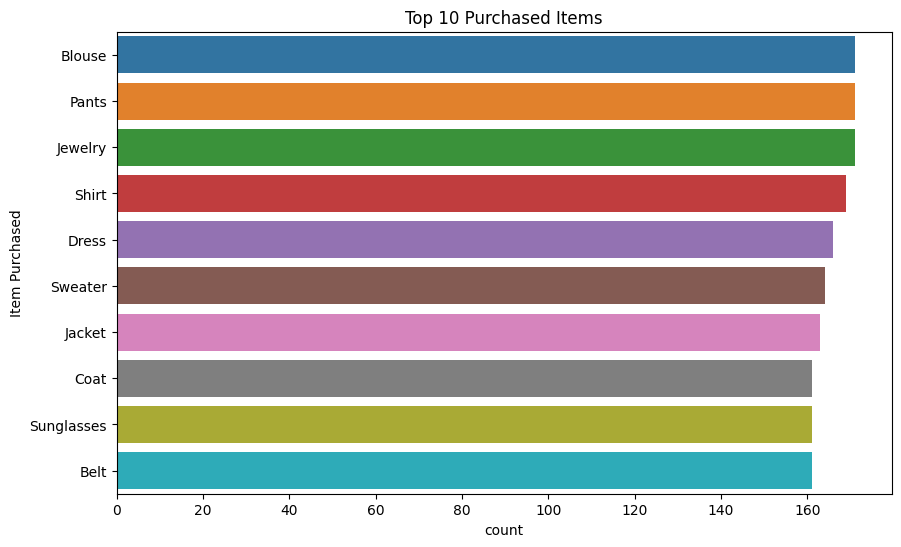

In [16]:
# TODO: plot a horizontal bar chart of the top 10 items with sns.barplot()
plt.figure(figsize=(10, 6))
sb.barplot(
    data=top_item.head(10),
    y='Item Purchased',
    x='count',
    hue='Item Purchased',
    dodge=False,
    legend=False
)
plt.title("Top 10 Purchased Items")
plt.xlabel('count')
plt.ylabel('Item Purchased')
plt.show()

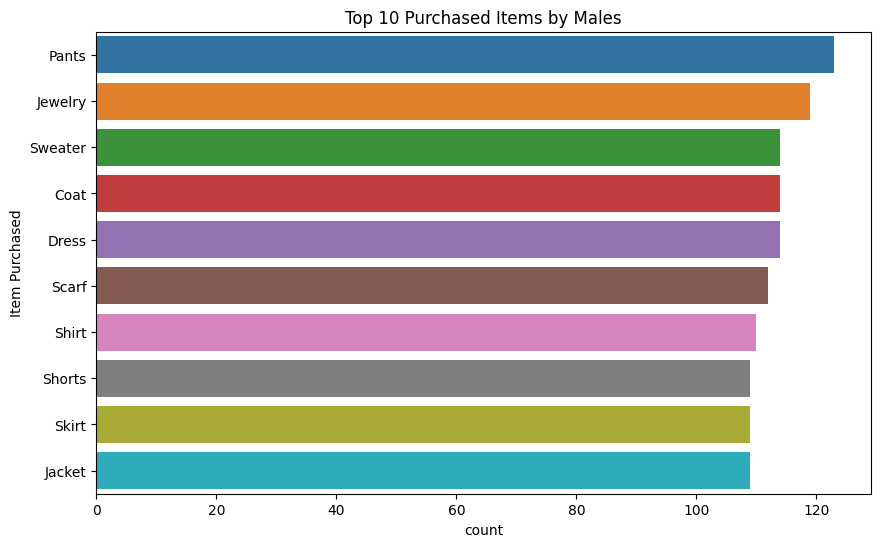

In [17]:
# TODO: plot a horizontal bar chart of the top 10 items for males with sns.barplot()
plt.figure(figsize=(10, 6))
sb.barplot(
    data=top_item_nam.head(10),
    y='Item Purchased',
    x='count',
    hue='Item Purchased',
    dodge=False,
    legend=False
)
plt.title("Top 10 Purchased Items by Males")
plt.xlabel('count')
plt.ylabel('Item Purchased')
plt.show()

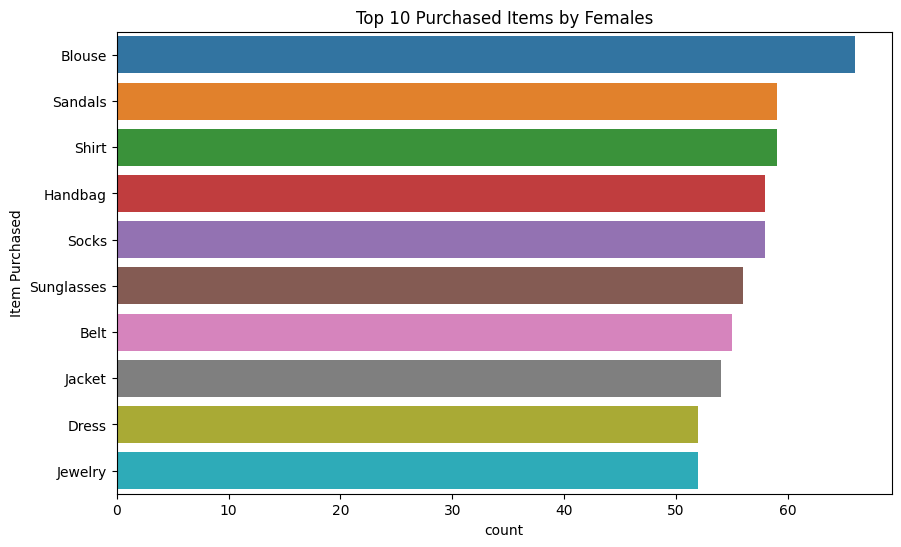

In [18]:
# TODO: plot a horizontal bar chart of the top 10 items for females with sns.barplot()
plt.figure(figsize=(10, 6))
sb.barplot(
    data=top_item_nu.head(10),
    y='Item Purchased',
    x='count',
    hue='Item Purchased',
    dodge=False,
    legend=False
)
plt.title("Top 10 Purchased Items by Females")
plt.xlabel('count')
plt.ylabel('Item Purchased')
plt.show()

In [19]:
# TODO: count Size with value_counts() for all customers
size = df['Size'].value_counts()
size

Size
M     1755
L     1053
S      663
XL     429
Name: count, dtype: int64

In [20]:
# TODO: count Size with value_counts() for male_df and female_df
size_nam = nam_df['Size'].value_counts()
size_nu = nu_df['Size'].value_counts()

size_nam, size_nu

(Size
 M     1165
 L      716
 S      476
 XL     295
 Name: count, dtype: int64,
 Size
 M     590
 L     337
 S     187
 XL    134
 Name: count, dtype: int64)

### **Category**

In [21]:
# TODO: count Category with value_counts().reset_index() for all customers
ctg = df['Category'].value_counts().reset_index()

In [22]:
# TODO: count Category with value_counts().reset_index() for male_df and female_df
ctg_nam = nam_df['Category'].value_counts().reset_index()
ctg_nu = nu_df['Category'].value_counts().reset_index()

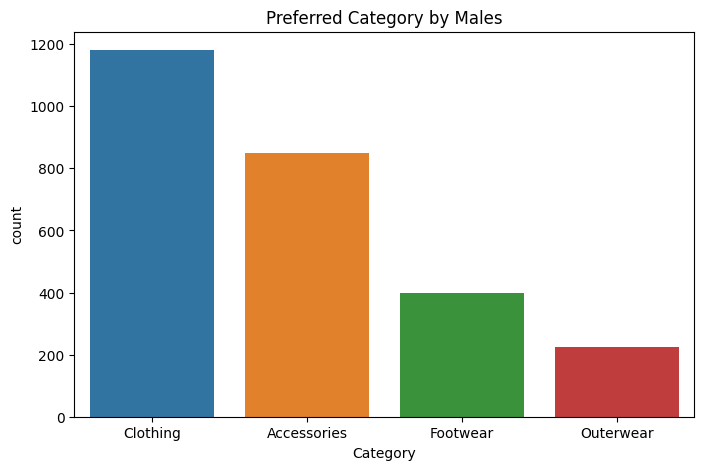

In [23]:
# TODO: plot a bar chart of preferred Category for males with sns.barplot()
plt.figure(figsize=(8, 5))
sb.barplot(
    data=ctg_nam,
    x='Category',
    y='count',
    hue='Category',
    dodge=False,
    legend=False
)
plt.title("Preferred Category by Males")
plt.xlabel('Category')
plt.ylabel('count')
plt.show()

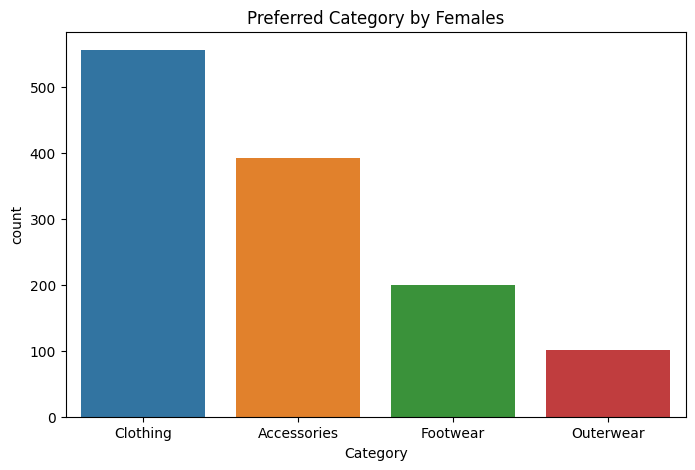

In [24]:
# TODO: plot a bar chart of preferred Category for females with sns.barplot()
plt.figure(figsize=(8, 5))
sb.barplot(
    data=ctg_nu,
    x='Category',
    y='count',
    hue='Category',
    dodge=False,
    legend=False
)
plt.title("Preferred Category by Females")
plt.xlabel('Category')
plt.ylabel('count')
plt.show()

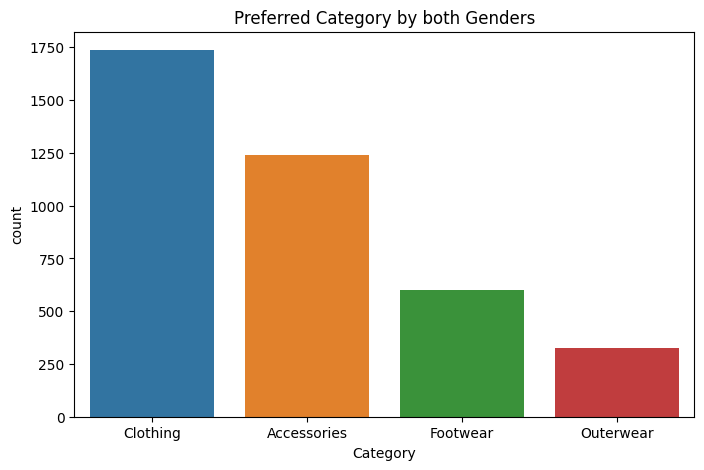

In [25]:
# TODO: plot a bar chart of preferred Category for both genders with sns.barplot()
plt.figure(figsize=(8, 5))
sb.barplot(
    data=ctg,
    x='Category',
    y='count',
    hue='Category',
    dodge=False,
    legend=False
)
plt.title("Preferred Category by both Genders")
plt.show()

In [26]:
# TODO: create waffle_data_m and waffle_data_f from Category value_counts()
waffle_data_nam = dict(nam_df['Category'].value_counts())
waffle_data_nu = dict(nu_df['Category'].value_counts())


# TODO: create waffle_data_f from female_df['Category'].value_counts()


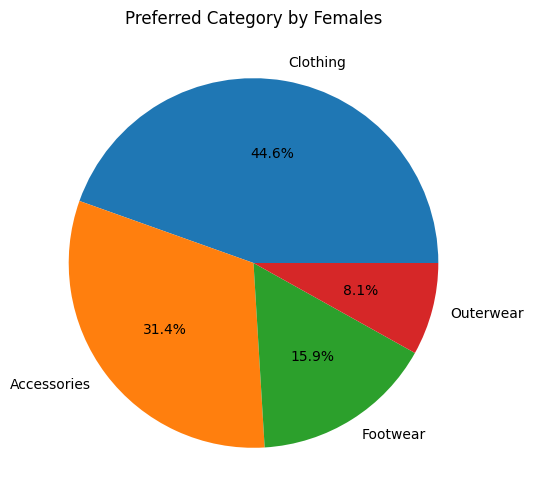

In [27]:
# TODO: plot a pie chart of preferred Category for females with plt.pie()
plt.figure(figsize=(6, 6))
plt.pie(
    waffle_data_nu.values(),
    labels=waffle_data_nu.keys(),
    autopct='%1.1f%%'
)
plt.title("Preferred Category by Females")
plt.show()

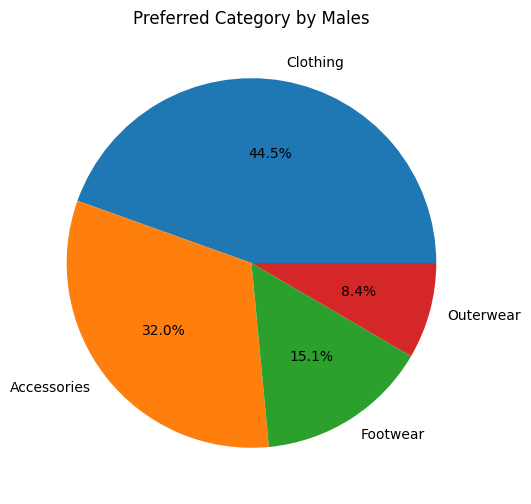

In [28]:
# TODO: plot a pie chart of preferred Category for males with plt.pie()
plt.figure(figsize=(6, 6))
plt.pie(
      waffle_data_nam.values(),
      labels=waffle_data_nam.keys(),
      autopct='%1.1f%%'
)
plt.title("Preferred Category by Males")
plt.show() 

### **Review ratings**

In [29]:
# TODO: filter female Clothing rows, then mean of Review Rating
cr_nu = nu_df[nu_df['Category'] == 'Clothing']
avg_cr_nu = cr_nu['Review Rating'].mean()

In [30]:
# TODO: filter male Clothing rows, then mean of Review Rating
cr_nam = nam_df[nam_df['Category'] == 'Clothing']
avg_cr_nam = cr_nam['Review Rating'].mean()

In [34]:
print(avg_cr_nam)

3.7319220999153258


In [35]:
print(avg_cr_nu)

3.7044964028776977


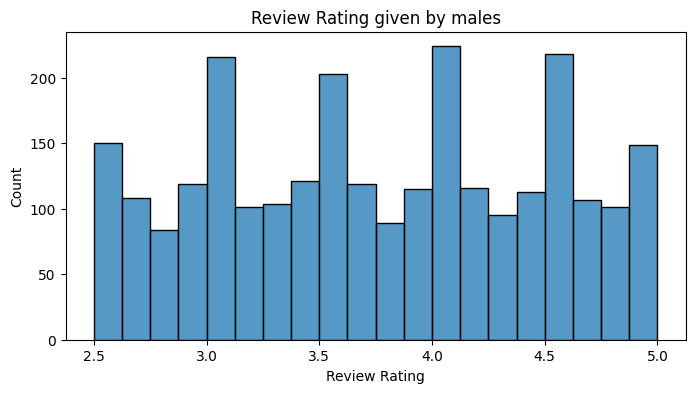

In [36]:
# TODO: plot Review Rating histograms for males and females with sns.histplot()
# males
plt.figure(figsize=(8, 4))
sb.histplot(data=nam_df, x='Review Rating', bins=20)
plt.title("Review Rating given by males")
plt.show()

# females
# ?

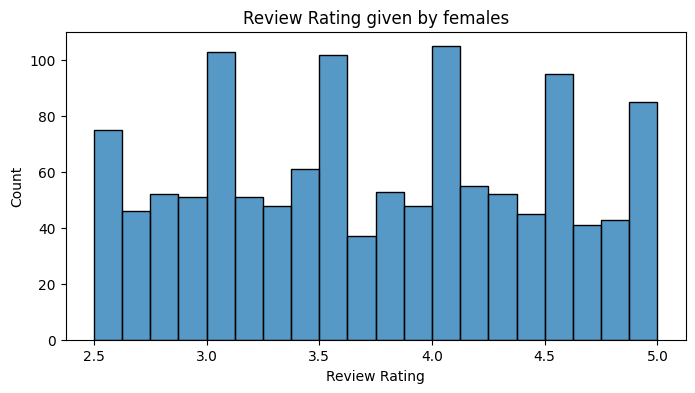

In [37]:
plt.figure(figsize=(8, 4))
sb.histplot(data=nu_df, x='Review Rating', bins=20)
plt.title("Review Rating given by females")
plt.show()

In [38]:
# TODO: count Review Rating with value_counts() for male Clothing (cr_m)
cr_nam['Review Rating'].value_counts()

Review Rating
3.7    61
3.4    59
2.7    55
2.9    55
4.0    52
4.2    52
3.9    52
3.3    49
3.0    49
4.9    48
4.1    48
3.5    48
3.1    46
4.7    46
4.6    46
3.6    46
4.8    46
2.6    45
4.3    45
4.4    43
3.2    41
2.8    41
3.8    39
4.5    36
2.5    17
5.0    16
Name: count, dtype: int64

### **Purchase Amount (USD)**

In [40]:
# TODO: sum Purchase Amount (USD) for males
nam_tpa = nam_df['Purchase Amount (USD)'].sum()
nu_tpa = nu_df['Purchase Amount (USD)'].sum()

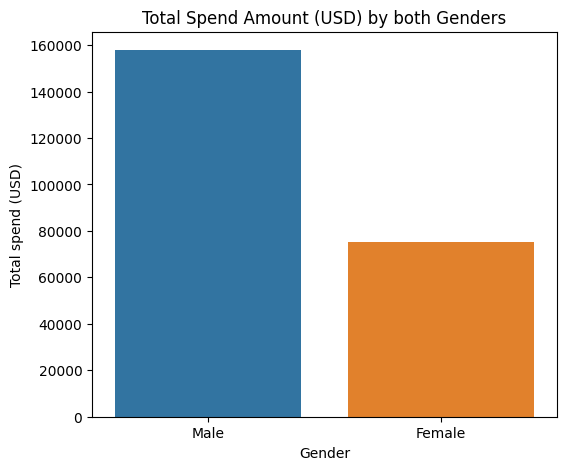

In [41]:
# TODO: plot total spend by gender with sns.barplot()
spend_gender = pd.DataFrame({
    'Gender': ['Male', 'Female'],
    'Total Spend': [nam_tpa, nu_tpa]
})

plt.figure(figsize=(6, 5))
sb.barplot(
    data=spend_gender,
    x='Gender',
    y='Total Spend',
    hue='Gender',
    dodge=False,
    legend=False
)
plt.title("Total Spend Amount (USD) by both Genders")
plt.ylabel('Total spend (USD)')
plt.show()

In [42]:
# TODO: filter female_df by Category: Clothing, Accessories, Footwear, Outerwear
cc_nu = cr_nu
ca_nu = nu_df[nu_df['Category'] == 'Accessories']
cf_nu = nu_df[nu_df['Category'] == 'Footwear']
co_nu = nu_df[nu_df['Category'] == 'Outerwear']

In [43]:
# TODO: filter male_df by Category: Clothing, Accessories, Footwear, Outerwear
cc_nam = cr_nam
ca_nam = nam_df[nam_df['Category'] == 'Accessories']
cf_nam = nam_df[nam_df['Category'] == 'Footwear']
co_nam = nam_df[nam_df['Category'] == 'Outerwear']

In [44]:
# TODO: create pcu dict from Promo Code Used value_counts()
pcu = dict(df['Promo Code Used'].value_counts())
pcu

{'No': np.int64(2223), 'Yes': np.int64(1677)}

### **Relationships (multivariate)**

Numeric columns only: Age, Purchase Amount (USD), Review Rating, Previous Purchases.

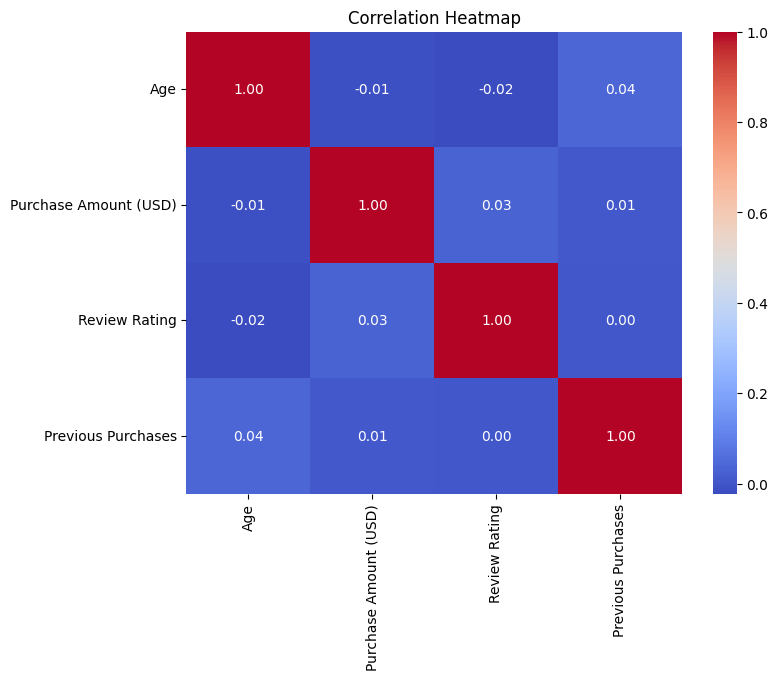

In [45]:
# TODO: compute correlation with df.corr(numeric_only=True), then plot a heatmap with sns.heatmap()
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sb.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Correlation Heatmap")
plt.show()

### **Feature engineering**

Dummy variables for columns with few levels. Scale numeric columns (keep originals). Bin purchase amount.

In [46]:
# TODO: dummy variables for Gender, Size, and Category with pd.get_dummies()
df = pd.get_dummies(
    df,
    columns=['Gender', 'Size', 'Category'],
    dtype=int
)

df.head()

,Age,Item Purchased,Purchase Amount (USD),Location,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,...,Gender_Female,Gender_Male,Size_L,Size_M,Size_S,Size_XL,Category_Accessories,Category_Clothing,Category_Footwear,Category_Outerwear
0,55,Blouse,53,Kentucky,Gray,Winter,3.1,Yes,Credit Card,Express,...,0,1,1,0,0,0,0,1,0,0
1,19,Sweater,64,Maine,Maroon,Winter,3.1,Yes,Bank Transfer,Express,...,0,1,1,0,0,0,0,1,0,0
2,50,Jeans,73,Massachusetts,Maroon,Spring,3.1,Yes,Cash,Free Shipping,...,0,1,0,0,1,0,0,1,0,0
3,21,Sandals,90,Rhode Island,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,...,0,1,0,1,0,0,0,0,1,0
4,45,Blouse,49,Oregon,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,...,0,1,0,1,0,0,0,1,0,0


In [47]:
# TODO: use MinMaxScaler on Purchase Amount (USD) and StandardScaler on Age (keep original columns)
from sklearn.preprocessing import MinMaxScaler, StandardScaler

minmax = MinMaxScaler()
standard = StandardScaler()

df['Amount_minmax'] = minmax.fit_transform(
    df[['Purchase Amount (USD)']]
)

df['Age_standard'] = standard.fit_transform(
    df[['Age']]
)

df[['Purchase Amount (USD)', 'Amount_minmax', 'Age', 'Age_standard']].head()

,Purchase Amount (USD),Amount_minmax,Age,Age_standard
0,53,0.4125,55,0.718913
1,64,0.5500,19,-1.648629
2,73,0.6625,50,0.390088
3,90,0.8750,21,-1.517099
4,49,0.3625,45,0.061263


In [48]:
# TODO: use pd.cut() to bin Purchase Amount (USD) into Low / Medium / High
df['Amount_bin'] = pd.cut(
    df['Purchase Amount (USD)'],
    bins=[0, 40, 70, 100],
    labels=['Low', 'Medium', 'High']
)
df['Amount_bin'].value_counts()

Amount_bin
High      1447
Medium    1393
Low       1060
Name: count, dtype: int64

### **Summary**

Write 4–5 insights from the plots. These are associations, not causal claims.

Examples to check:
- Which items and categories are most common for males vs females?
- Do males and females spend a similar total amount?
- Is Review Rating similar across genders?
- How often is a promo code used?

# TODO: write insights
- Các mặt hàng được khách hàng nam và nữ mua nhiều nhất có sự khác nhau
- Clothing (Quần áo) là một trong những nhóm sản phẩm phổ biến ở cả nam và nữ
- Tổng số tiền chi tiêu của khách hàng nam và nữ tương đối gần nhau
- Điểm đánh giá sản phẩm của khách hàng nam và nữ nhìn chung không có sự khác biệt lớn
- Một bộ phận khách hàng có sử dụng mã khuyến mãi khi mua hàng
- Việc phân tích dữ liệu theo giới tính giúp hiểu rõ hơn về hành vi và sở thích mua sắm của khách hàng

Caveat: correlation is not causation.